<a href="https://colab.research.google.com/github/Andremil/tcc/blob/main/tccdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install metapub
!pip install pdfplumber
!pip install fitz
!pip install frontend
!pip install PyMuPDF
!pip install PyPDF2

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.4/147.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.9/120.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.5/235.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 36.4 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=0109a4e4745035a1290c56081164a60b13a07697cd3e8484998a5e03aba82019
  Stored in directory: /root/.cache/pip/wheels/1a/b0/8c/4b75c4116c31f83c8f9f047231251e13cc74481cca4a78a9ce
Successfully built docopt
  Attempting uninstall: urllib3
    Found

In [ ]:
import numpy as np
import pandas as pd
import json
from metapub import PubMedFetcher

2025-04-02 18:28:15 a2194753dc30 metapub.config[185] WARNING NCBI_API_KEY was not set.


In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
import csv
from metapub import PubMedFetcher
import io  # Importe io para usar StringIO

# Initialize the fetcher
fetcher = PubMedFetcher()

# Define a complex query including free full text and year range
query = '("human health" AND ("microplastics" OR "nanoplastics") AND ("toxicity" OR "health risk")) AND free full text[sb] AND "2010"[Date - Publication] : "2024"[Date - Publication]'

# Fetch PMIDs for the complex query
pmids = fetcher.pmids_for_query(query)

# Lista de propriedades para extrair com base na verificação de propriedades disponíveis
properties = [
    'abstract', 'author1_last_fm', 'author1_lastfm', 'author_list', 'authors', 'authors_str',
    'book_abstracts', 'book_accession_id', 'book_contribution_date', 'book_copyright',
    'book_date_revised', 'book_editors', 'book_history', 'book_language', 'book_medium',
    'book_publication_status', 'book_publisher', 'book_sections', 'book_synonyms',
    'book_title', 'chemicals', 'citation', 'citation_html', 'content', 'doi', 'first_page',
    'grants', 'history', 'issn', 'issue', 'journal', 'last_page', 'mesh', 'pages', 'parse_xml',
    'pii', 'pmc', 'pmid', 'pmcid', 'publication_types', 'pubmed_type', 'title', 'to_dict', 'url',
    'volume', 'volume_issue', 'xml', 'year'
]


# Nome do arquivo CSV
csv_filename = 'articles.csv'

# Lista para armazenar os dados dos artigos
article_data_list = []

# Iterar pelos PMIDs e obter os dados dos artigos
for pmid in pmids:
    article = fetcher.article_by_pmid(pmid)
    article_data = []

    # Iterar pelas propriedades e extrair os dados do artigo
    for prop in properties:
        if hasattr(article, prop):
            article_data.append(getattr(article, prop))
        else:
            article_data.append('')  # Se a propriedade não estiver disponível, adicione uma string vazia

    # Adicionar os dados do artigo à lista
    article_data_list.append(article_data)

# Escrever os dados no arquivo CSV
with open(csv_filename, 'w', newline='', encoding='utf-8') as csvfile:
    csvwriter = csv.writer(csvfile)

    # Escrever o cabeçalho com os nomes das propriedades
    csvwriter.writerow(properties)

    # Escrever os dados de cada artigo
    csvwriter.writerows(article_data_list)

print(f"Dados dos artigos foram salvos em {csv_filename}")


Dados dos artigos foram salvos em articles.csv


In [ ]:
data = pd.read_csv(csv_filename)

In [ ]:
data.to_csv('drive/My Drive/data_20241231.csv')

In [ ]:
data = pd.read_csv('drive/My Drive/data_20241231.csv')

In [ ]:
df = data.iloc[:,1:]

In [ ]:
# Definindo as listas de termos para cada categoria a ser filtrada a partir do abstract



In [ ]:
objective_terms = [
    "objective", "aim", "purpose", "goal", "research question", "hypothesis", "focus", "intent", "problem", "study design",
    "research aim", "study purpose", "research goal", "study objective", "research focus", "investigation objective", "main goal", "primary goal",
    "study hypothesis", "central aim", "primary objective", "intended purpose"
]


In [ ]:
method_terms = [
    "methodology", "method", "approach", "technique", "design", "data collection", "procedure", "experiment", "analysis", "sampling",
    "instrument", "statistical analysis", "research method", "research design", "data analysis", "experimental method", "quantitative method",
    "qualitative method", "survey", "measurement", "testing", "protocol", "statistical procedure", "research approach", "empirical method",
    "data gathering", "data collection process"
]


In [ ]:
result_terms = [
    "results", "findings", "outcome", "data", "analysis results", "discovery", "observation", "significant", "association", "impact",
    "difference", "effect", "conclusion", "findings indicate", "results suggest", "evidence shows", "observed", "significant difference",
    "statistical result", "outcome shows", "data analysis", "key results", "major findings", "main outcome"
]


In [ ]:
conclusion_terms = [
    "conclusion", "implications", "recommendations", "consequence", "suggestion", "interpretation", "summary", "contribution",
    "practical implications", "future work", "limitations", "final thoughts", "research implications", "study conclusion", "key takeaways",
    "main conclusion", "research recommendations", "interpretation of results", "study limitations", "future directions", "policy implications"
]


In [ ]:
human_health_terms = [
    "health", "disease", "illness", "condition", "disorder", "sickness", "infection", "toxin", "poison",
    "virus", "bacteria", "pathogen", "cancer", "heart disease", "stroke", "hypertension", "diabetes", "obesity",
    "respiratory disease", "respiratory", "lungs", "kidney disease", "neurological disorder", "mental health",
    "depression", "anxiety", "psychological health", "physical health", "well-being", "wellness", "immune system",
    "immune response", "inflammation", "immune", "autoimmunity", "autoimmune", "chronic", "acute", "prevention",
    "treatment", "therapy", "medication", "vaccine", "clinical", "epidemiology", "infection", "disease prevention",
    "health promotion", "healthcare", "health risks", "health management", "health surveillance", "health outcomes",
    "health monitoring", "health impact", "medical", "care", "health protection", "health assessment", "health studies",
    "public health", "public health risk", "health policy", "health crisis", "health systems", "health services",
    "health interventions", "disease outbreaks", "pandemic", "endemic", "vaccine", "prevalence", "incidence",
    "healthcare access", "treatment outcomes", "risk factors", "exposure", "air quality", "water quality", "pollution",
    "chemical exposure", "environmental health", "environmental effects", "biomedical", "biomarker", "epigenetics",
    "genetic risk", "genetics", "genomic", "microbiome", "toxicology", "heavy metals", "toxic", "cancer risk",
    "long-term effects", "acute effects", "adverse effects", "health risks of exposure", "health hazard", "health assessment",
    "health surveillance", "toxicity", "biological effects", "disease burden", "morbidity", "mortality", "longevity",
    "aging", "genetic disorders", "genetic predisposition", "chronic conditions", "mental disorders", "brain health",
    "nervous system", "neurodegenerative", "neurology", "cognitive function", "neurodevelopment", "musculoskeletal",
    "muscle health", "bone health", "cardiovascular", "heart health", "stroke risk", "diabetes risk", "hypertension risk",
    "cardiovascular disease", "cerebrovascular", "diabetes prevention", "nutrition", "diet", "lifestyle", "dietary habits",
    "physical activity", "obesity prevention", "exercise", "fitness", "active lifestyle", "physical fitness",
    "dietary factors", "nutritional deficiency", "vitamin deficiency", "malnutrition", "overweight", "underweight",
    "obesity", "fatigue", "sleep", "sleep disorders", "mental well-being", "psychosocial health", "behavioral health",
    "mental illness", "social determinants", "health disparity", "health equity", "health inequalities", "health risks",
    "life expectancy", "disability", "disability-adjusted life years", "social health", "community health",
    "socioeconomic health", "vulnerable populations", "aging population", "infant health", "child health", "adolescent health",
    "elderly health", "maternal health", "women's health", "men's health", "sexual health", "reproductive health",
    "fertility", "health screening", "preventive care", "health education", "health literacy", "health information",
    "health technology", "digital health", "telemedicine", "eHealth", "personalized medicine", "precision medicine",
    "genetic screening", "public health surveillance", "disease surveillance", "pandemic response", "health response",
    "health crisis management", "disaster health", "environmental risk", "environmental exposure", "pollutant exposure",
    "chemical exposure", "contamination", "waterborne disease", "airborne disease", "health interventions", "infection control",
    "disease control", "biological contamination", "contaminants", "biological risk", "chemical risk", "health research"
]


In [ ]:
# Filtrando os abstracts com pelo menos um termo de cada categoria
df_filtered = df[
    df['abstract'].str.contains("|".join(objective_terms), case=False, na=False) &
    df['abstract'].str.contains("|".join(method_terms), case=False, na=False) &
    df['abstract'].str.contains("|".join(result_terms), case=False, na=False) &
    df['abstract'].str.contains("|".join(conclusion_terms), case=False, na=False) &
    df['abstract'].str.contains("|".join(human_health_terms), case=False, na=False)
]

In [ ]:
len(df_filtered)

32

In [ ]:
# salvando os dados filtrados como df_filtered.csv
df_filtered.to_csv('drive/My Drive/df_filtered.csv')

In [ ]:
#lendo os dados filtrados a partir do google drive
df = pd.read_csv('drive/My Drive/df_filtered.csv')


In [ ]:
#selecionando colunas mais relevantes para os nossa base de dados final
df_tcc = df_filtered[['abstract', 'authors', 'chemicals', 'citation', 'doi', 'history', 'issn', 'journal', 'title', 'volume', 'volume_issue', 'year', 'publication_types_extracted', 'url','history']]



In [ ]:
#salvando no drive novamente como tccData.csv
df_tcc.to_csv('drive/My Drive/tccData.csv')

In [ ]:
#lendo do drive novamente como tccData.csv
df = pd.read_csv('drive/My Drive/tccData.csv')


In [ ]:
#inserindo colunas para objetivos, metodologia e resultados
df.insert(2, "objectives", [None] * len(df))   # Insere na posição 2
df.insert(3, "methodology", [None] * len(df))  # Insere na posição 3
df.insert(4, "results", [None] * len(df))      # Insere na posição 4
# salvando dados para analise manual
df.to_csv('drive/My Drive/mydata.csv')

In [ ]:
# realizada analise manual a partir do resumo e exluido alguns artigos motivo da exclusão abaixo
# inserida coluna participaintginstituitions obtidas a partir da ulr dos resumo no pubmed

In [ ]:
'''article index 5 :This article will be excluded from your research as it does not focus on in vivo human species studies. It centers on ecological effects using zebrafish as a model.

article index 9:The article is based on animal studies (mice), which do not involve human species, and therefore, it will be excluded from your research on human health impacts.

article index 10:Although it offers valuable insights into the need for standardized protocols for NMPs in toxicity studies, this article does not provide direct empirical data on the effects of NMP exposure on human health. Therefore, it doesn't directly contribute to your research on the human health impact of microplastics.

article index 11: This study is excluded because it uses an in vitro model (Caco-2 cells) rather than in vivo human species. Although it investigates the impact of micro- and nanoplastics on human health, the focus is on laboratory-grown human cells, not actual human subjects. For your research, you are focusing on studies that directly involve human species in vivo, which this study does not meet.

article index 12: The study uses mice, not human species, so it falls outside your criteria of in vivo human species. Therefore, this article will be excluded from your research.

article index 13: The study involves zebrafish larvae, not human species, and thus does not meet the criteria of being in vivo human species. Therefore, this article will be excluded from your research.

article index 14: Although the study is focused on mice, not humans, the research investigates the potential human health implications by using an in vivo animal model. Therefore, while the study is not directly about humans, it provides valuable insights into the potential effects on human health, so it remains relevant for your research.

article index 17: The study is excluded because it primarily focuses on zebrafish as a model organism rather than directly investigating human species or human-specific in vivo effects.

article index 18: This study is excluded because it primarily focuses on landfill leachate and its associated pollutants, rather than the direct effects of microplastics or nanoplastics on human health. While it addresses ecological and human health risks from pollutants found in landfills, it does not directly investigate the toxicity of microplastics or nanoplastics and their specific impacts on human physiology or health. Therefore, its relevance to our focus on microplastics is limited.

article index 21: The study is not directly about humans but involves in vitro and in vivo models, including mice. The in vitro experiments were conducted on dopaminergic-differentiated SH-SY5Y cells, and in vivo experiments were performed in C57BL/6 J mice.


article index 23: No, the study is not directly on humans. It uses zebrafish embryos as a model to assess the effects of polyethylene microplastics (PE-MPs), with implications for human health based on the findings.



article index 24: This article is excluded because it does not focus on the direct effects of microplastics or nanoplastics on human health. Instead, it presents a bibliometric analysis of the broader research field on toxicity and the gastrointestinal microbiome.

article index 25 : This article is not directly about humans in vivo. It discusses the toxicity of microplastics and nanoplastics in vitro, focusing on experimental models and methodologies, not human studies.

article index 27: the article does not directly address how microplastics and nanoplastics affect human health. It focuses more on detection and separation methods for microplastics.

article index 30: It is not directly about human species, as it includes both in vitro and in vivo studies on various species, not specifically humans.

article index 31: This article is about the ecotoxicological risks of plastic pollution in aquatic biota and its indirect effects through contamination but does not focus on direct human health outcomes.
'''

"article index 5 :This article will be excluded from your research as it does not focus on in vivo human species studies. It centers on ecological effects using zebrafish as a model.\n\narticle index 9:The article is based on animal studies (mice), which do not involve human species, and therefore, it will be excluded from your research on human health impacts.\n\narticle index 10:Although it offers valuable insights into the need for standardized protocols for NMPs in toxicity studies, this article does not provide direct empirical data on the effects of NMP exposure on human health. Therefore, it doesn't directly contribute to your research on the human health impact of microplastics.\n\narticle index 11: This study is excluded because it uses an in vitro model (Caco-2 cells) rather than in vivo human species. Although it investigates the impact of micro- and nanoplastics on human health, the focus is on laboratory-grown human cells, not actual human subjects. For your research, you 

In [ ]:
#carregando base de dados final:
dados = pd.read_csv('drive/My Drive/finaldatacsv.csv')

2025-03-24 21:12:22 d35e942ee7fd matplotlib.category[306] INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
<ipython-input-23-16f179469cab>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dados, x='year', palette='Blues')  # Use o palette para cores mais atraentes
2025-03-24 21:12:22 d35e942ee7fd matplotlib.category[306] INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


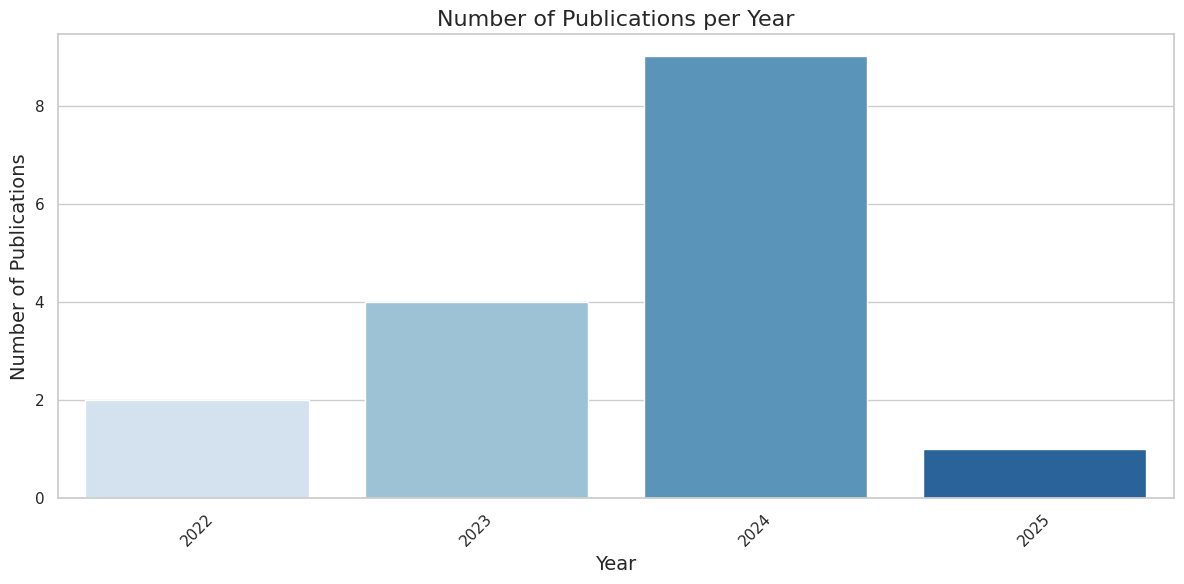

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Vamos usar a função 'countplot' do seaborn para contar os valores por ano
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")  # Definindo o estilo de fundo para o gráfico
sns.countplot(data=dados, x='year', palette='Blues')  # Use o palette para cores mais atraentes

plt.title('Number of Publications per Year', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Publications', fontsize=14)
plt.xticks(rotation=45)  # Rotaciona os rótulos do eixo x, caso necessário
plt.tight_layout()  # Ajusta o layout para não cortar texto
plt.show()



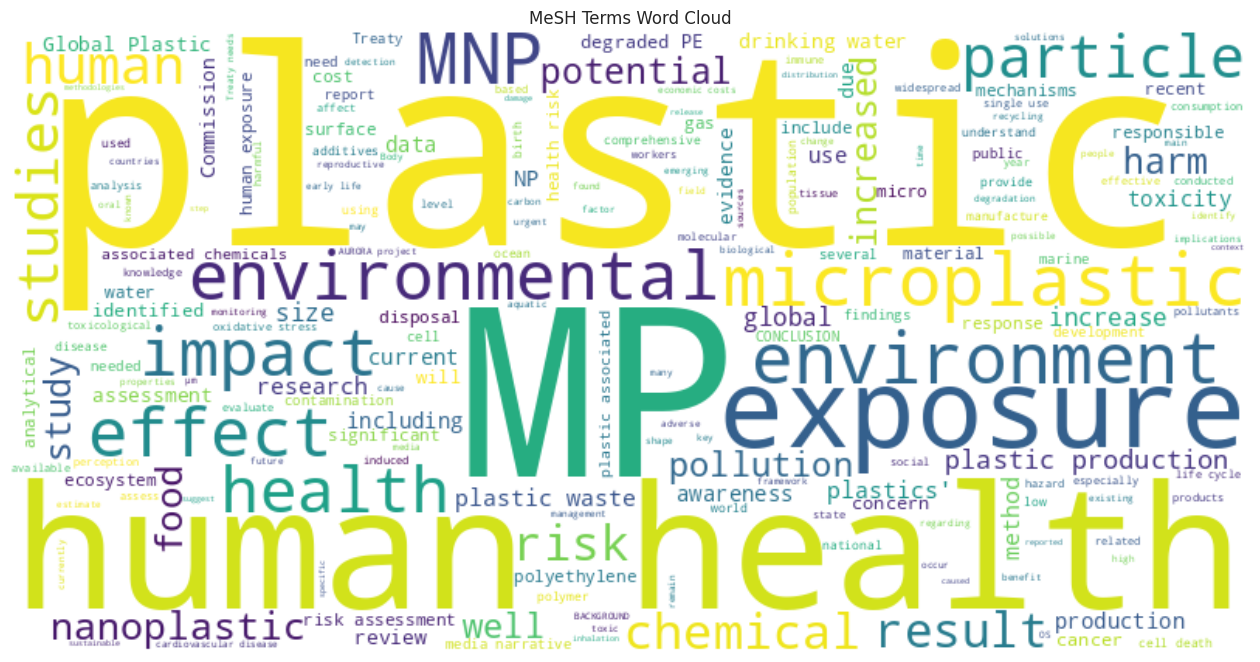

In [ ]:
from wordcloud import WordCloud

# Generating the word cloud for MeSH terms
text = ' '.join(dados['abstract'].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(16, 12))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('MeSH Terms Word Cloud')
plt.show()